Building likelihood maps for a set of representative images.

> TODO: use images from dataset and superimpose the bounding boxes on them

In [1]:
from retinotopy import *

Running on GPU :  NVIDIA GeForce RTX 3060 #GPU= 1
---------------------------------------------------------------------------------------------------
On date 2024-05-24, Running learning on host DESKTOP-27VNO0E with device cuda, pytorch==2.2.0+cu121
---------------------------------------------------------------------------------------------------
Welcome on Linux-5.10.16.3-microsoft-standard-WSL2-x86_64-with-glibc2.35
Random seed 1998 has been set.


In [2]:
# The dataset to import images from

data_set_type = 'full'
args = Params()
args.root  = f'{DATAROOT}/Imagenet_{data_set_type}' # Directory containing images
args.folders = ['val'] # type of images to use

args.do_saccade = True
args.do_resize = False
args.do_mask = False
args.do_polar = False

## doing the computations

Params(datetag='2024-05-24', loader='/mnt/d/Data/Imagenet_urls_ILSVRC_2016.json', annotations_animal='/mnt/d/Data/Animal10k_annotations.json', annotations='/mnt/d/Data/LOC_val_solution_with_sizes.csv', folders=['val'], tasks=['animal', 'dog', 'cat', 'bird'], image_size=224, num_epochs=2, n_train_stop=0, seed=1998, batch_size=50, batch_size_val=50, lr=0.00015, momentum=0.06, beta2=0, rs_min=0.0, rs_max=-5.0, do_polar=False, do_raw=False, do_resize=False, do_mask=False, do_scratch=False, do_rotation=False, do_rot_train=False, resolution=(11, 11), size_ratio=0.5, do_saccade=True, do_zoom=False, method='full', saccade_type='grid', normalize=True)
Lets go last 1 uk ! 
model_data_set_type='bbox'
..................................................
args.do_polar=True
cached_data/2024-05-24_bbox_resnet101_retino_test_mean_map.parquet
..................................................
loading .... cached_data/2024-05-24_bbox_resnet101_retino.pt


1000it [08:22,  1.99it/s]


args.do_polar=False
cached_data/2024-05-24_bbox_resnet101_cartesian_test_mean_map.parquet
..................................................
loading .... cached_data/2024-05-24_bbox_resnet101_cartesian.pt


1000it [07:25,  2.25it/s]


model_data_set_type='raw'
..................................................
args.do_polar=False
cached_data/2024-05-24_raw_resnet101_cartesian_test_mean_map.parquet
..................................................


1000it [07:26,  2.24it/s]

args.do_polar=False
cached_data/2024-05-24_raw_resnet101_cartesian_test_mean_map.parquet


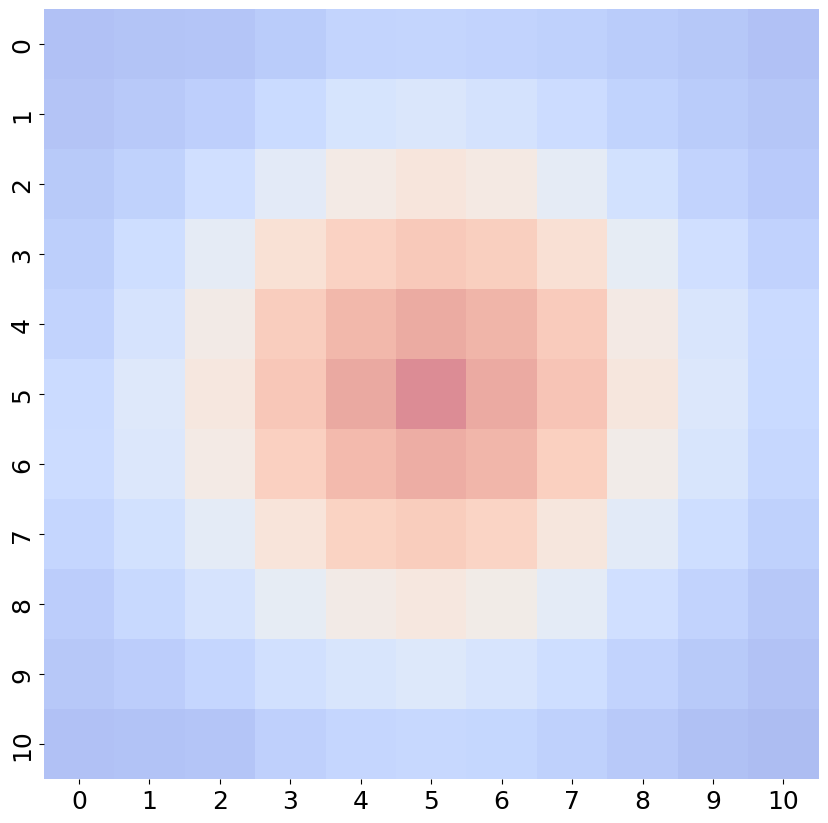

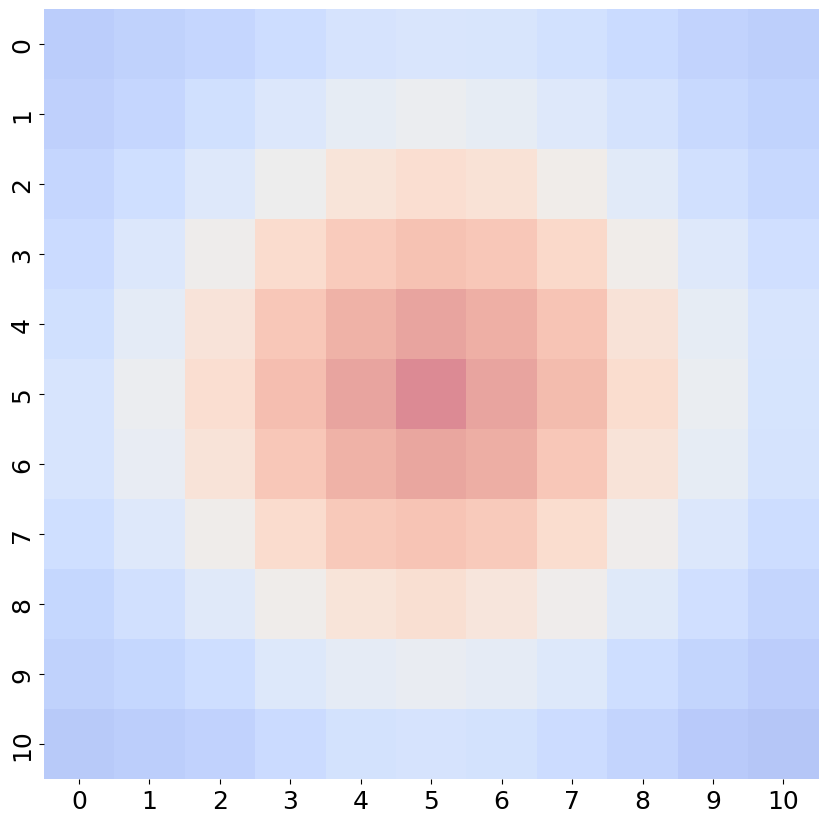

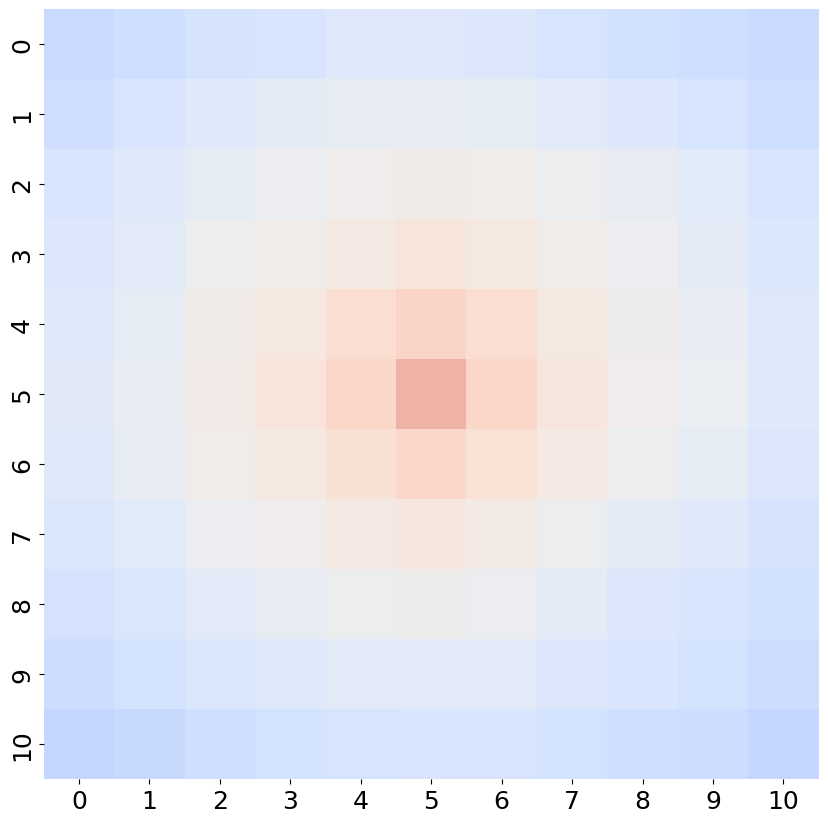

In [3]:
pos_pred_zero = ((args.resolution[0]*args.resolution[1])//2)
retino_grid = get_grid(args).unsqueeze(0).to(device)
print(args)

print('Lets go last 1 uk manu go! ')
annotations = None
#for model_data_set_type in data_set_types:
for model_data_set_type in ['bbox', 'raw']:
    print(50*'=')
    print(f'{model_data_set_type=}')    
    
    for model_name in  ['resnet101']:
    #for model_name in  ['resnet18', 'resnet50', 'resnet101']:
        print(50*'.')

        best_tresh = 0.2 if model_name == 'resnet18' else 0.1
        sum_map = []
        for do_polar in [True, False]:

            do_polar = do_polar if model_data_set_type != 'raw' else False

            args.do_polar = do_polar
            print(f'{args.do_polar=}')

            df_filename = get_filename(data_cache, datetag, model_data_set_type, model_name, do_polar) + f'_test_mean_map_complete.parquet'
            print(df_filename)
            
            if os.path.isfile(df_filename):
                continue
            else:
                df_map = None
                
                print(50*'.')
                
                model_filename = get_filename(data_cache, datetag, model_data_set_type, model_name, do_polar) + '.pt' if model_data_set_type != 'raw' else None

                #model_filename = f"cached_data/2024-03-04_{model_name}_do_polar={do_polar}_do_rottrain=False.pt"
                
                model = charge_model(model_name=model_name, model_path=model_filename, do_circular=args.do_polar).to(device).eval()
                
                if annotations is None:
                    annotations = get_annotation('csv')
                    df_filename_cam = get_filename(data_cache, datetag, 'raw', model_name, False) + f'_complete_gradcam.parquet'
                    annotations_cam = pd.read_parquet(df_filename_cam)

                with torch.no_grad():
                    image_datasets = image_datasets_transforms(args, shuffle=False, verbose=False)
                    #for indice in tqdm(indices):
                        #indice = int(indice)
                        #images, label = image_datasets[indice]
                    
                    for i_image, (images, label) in tqdm(enumerate(image_datasets)):

                        image_name = image_datasets.samples[i_image][0].split('/')[-1].split('.')[0]
                        
                        ground_true_indices, three_points, ground_true, origin_size = get_ground_true(args, image_name, annotations, 'Imagenet')
                        
                        if ground_true.min() == 0.0:
                            
                            since = time.time()
                            

                            
                            images = images.to(device, non_blocking=True)

                            heat_map = model(images)
                            heat_map = torch.nn.functional.softmax(heat_map, dim=1)
                            proba_label = heat_map[:, label].reshape(args.resolution)
                            arg_max_prior = torch.argmax(proba_label)
                            position_prior = (arg_max_prior.item()//min(args.resolution), arg_max_prior.item()%min(args.resolution))
                            sum_map.append(collect_centered_map(args, proba_label, position_prior))


                mean_map = torch.stack(sum_map).nanmean(dim=0)  
                mean_map = np.array(mean_map.cpu())
                #fig, ax = plt.subplots(1, 1, figsize=(10, 10))
                #sns.heatmap(mean_map, linewidth = 0 , annot = False, cmap='coolwarm', vmin=0, vmax=1, cbar = False, alpha=.5, ax=ax)
                mean_map = mean_map.reshape(args.resolution[0]*args.resolution[1])
                df_map_ = pd.DataFrame({'ImageId':[image_name], 'mean_map': [mean_map]})
                df_map = store_pandas(df_map, df_map_)
               
            df_map.to_parquet(df_filename)   